## XGBoost Regressor

The XGBoost Regressor is a more robus random forest model, aiming to calculate the strength of correlation between variables.

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
)

### 1. Read and clean data

In [3]:
# Load the dataset
data = pd.read_json("all_data.json")

In [4]:
# Print the number of missing values
print("Missing values in each column:")
print(data.isnull().sum())

# Drop or impute missing (na) values
data = data.dropna()

Missing values in each column:
Country Name                        0
year                                0
Foreign Investment                 63
GDP per Capita                     18
Unemployment Rate                  46
Labor Force participation rate     55
v4_prefixes_ris                     0
v6_prefixes_ris                     0
asns_ris                            0
v4_prefixes_stats                   0
v6_prefixes_stats                   0
asns_stats                          0
speed (mgps)                      181
bandwidth (kbit/s)                262
Income group                       45
imputed speed                       4
imputed bandwidth                   0
non_imputed_internet_index        401
imputed_internet_index              4
Economic Index_y                   81
dtype: int64


In [5]:
# Print the types of each variable
print("Data types of each column:")
cols = data.select_dtypes(include=["int64", "float64", "object"])
print(cols)

Data types of each column:
             Country Name  year  Foreign Investment  GDP per Capita  \
0                   qatar  2022            0.296388        0.345357   
3                   qatar  2018            0.294219        0.276485   
4                   qatar  2021            0.295267        0.279262   
6                   qatar  2019            0.293618        0.260113   
8                   qatar  2017            0.297261        0.246225   
..                    ...   ...                 ...             ...   
505  syrian arab republic  2020            0.297085        0.001698   
507                jordan  2018            0.297231        0.015631   
509                jordan  2022            0.297515        0.016360   
510                jordan  2020            0.297044        0.015150   
512                jordan  2021            0.296911        0.015780   

     Unemployment Rate  Labor Force participation rate  v4_prefixes_ris  \
0             0.000806                       

In [6]:
# Define the features and target variable
X = data[
    [
        "v4_prefixes_ris",
        "v6_prefixes_ris",
        "asns_ris",
        "asns_stats",
        "imputed speed",
        "imputed bandwidth",
    ]
]
y = data["Economic Index_y"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
print(y_train.isnull().sum())  # Check for NaN values
print(y_train.unique())  # Check unique values in y_train
print(y_train.value_counts())

0
[ 0.09720874  0.46395564  0.20177085  0.09480029  0.16906769  0.05152473
  0.1407576   0.12704778  0.43863278  0.22729067 -0.01680293  0.23819125
  0.18773879 -0.0286818   0.18290364  0.14406218  0.17456928  0.30246829
  0.05865634  0.08260589  0.20438573  0.04770972  0.2214139   0.25891283
  0.16975929  0.03827558  0.19269535  0.05273875 -0.02050853  0.2990777
  0.11971446  0.18011846  0.13859681  0.4993635   0.18583697  0.14517941
 -0.02684203  0.10206402  0.22342758  0.10251575  0.27700746  0.08362819
  0.09018786  0.28909644  0.37493005  0.13218178  0.03190045  0.43170992
  0.26011628  0.13572657  0.4788024   0.22939064  0.17552266  0.08902082
 -0.01737651  0.11300461  0.36845935  0.16498457  0.13713244  0.08964301
  0.52073695  0.01265285  0.00420963  0.20030206  0.14806912  0.19086969
  0.23725915  0.09992933  0.32724826  0.19321523  0.13070946  0.0678892
  0.06235197  0.33822205  0.26691778  0.01001385  0.12493498  0.19013483
  0.15289611  0.1980386   0.16116639  0.2443323   0

In [8]:
# Initiate the model
model = XGBRegressor(n_estimators=100, random_state=42, max_depth=7)

# Train the model
model.fit(X_train, y_train)

# Print the model to check the parameters used in training
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [9]:
# Make predicitions on the test data
y_pred = model.predict(X_test)

predictions = [value for value in y_pred]

# Print the predictions
print(predictions)

[np.float32(0.29760376), np.float32(0.12973632), np.float32(0.36016533), np.float32(0.14855455), np.float32(0.17595126), np.float32(0.15622526), np.float32(0.12108784), np.float32(0.1879963), np.float32(0.2669434), np.float32(0.1739492), np.float32(0.061023917), np.float32(0.10230109), np.float32(0.29276308), np.float32(0.16962554), np.float32(0.11272682), np.float32(0.11270732), np.float32(0.15751398), np.float32(0.24557507), np.float32(0.15612325), np.float32(0.18567652), np.float32(0.23952542), np.float32(0.04769332), np.float32(0.1387493), np.float32(-0.016044166), np.float32(0.12544443), np.float32(0.16774033), np.float32(0.1255713), np.float32(0.15512468), np.float32(0.1233539), np.float32(0.0064128833), np.float32(0.19009486), np.float32(0.25747955), np.float32(0.13037439), np.float32(0.20056084), np.float32(0.22988646), np.float32(-0.028696224), np.float32(0.1082863), np.float32(0.057303216), np.float32(0.26178065), np.float32(0.12311125)]


In [10]:
# Function for model description for regression
def describe_model(y_test, y_pred):
    mae = np.mean(np.abs(y_test - y_pred))
    mse = np.mean((y_test - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results = {
        "Mean absolute error": [mae],
        "Mean absolute error [%]": [mape],
        "Mean squared error": [mse],
        "Root mean squared error": [rmse],
        "R2 score": [r2],
    }

    results = pd.DataFrame(results)

    return results

In [11]:
# Compare the predictions on the training data vs the test data to check for overfitting
y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Predictions on test data
y_test_pred = model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test MSE: {test_mse:.2f}, R²: {test_r2:.2f}")

print(f"Training MSE: {train_mse:.2f}, R²: {train_r2:.2f}")

# Check y_test variance
print(f"Variance of y_test: {np.var(y_test):.2f}")

# Verify prediction alignment
assert len(y_test) == len(y_test_pred), "Mismatch in lengths of y_test and y_test_pred"

Test MSE: 0.00, R²: 0.50
Training MSE: 0.00, R²: 1.00
Variance of y_test: 0.01


In [12]:
# Get results
results = describe_model(y_test, y_pred)
results

,Mean absolute error,Mean absolute error [%],Mean squared error,Root mean squared error,R2 score
0,0.05083,0.366579,0.004738,0.06883,0.504465


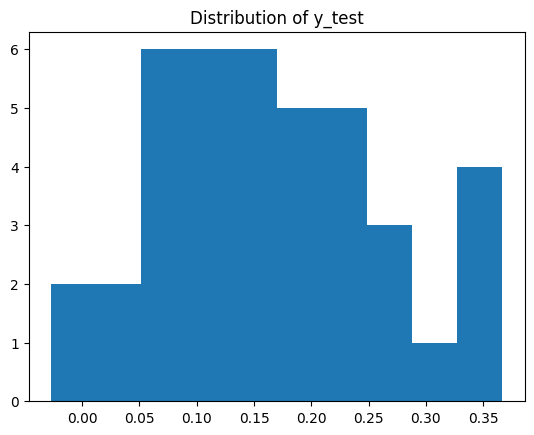

In [13]:
import matplotlib.pyplot as plt

plt.hist(y_test, bins=10)
plt.title("Distribution of y_test")
plt.show()

In [14]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 0.00
R^2 Score: 0.50


In [15]:
# These metrics are less sensitive to target variable variance
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f"Test MAE: {test_mae:.2f}")

test_rmse = np.sqrt(test_mse)
print(f"Test RMSE: {test_rmse:.2f}")

train_mae = mean_absolute_error(y_train, y_train_pred)
print(f"Train MAE: {train_mae:.2f}")

train_rmse = np.sqrt(train_mse)
print(f"Train RMSE: {train_rmse:.2f}")

Test MAE: 0.05
Test RMSE: 0.07
Train MAE: 0.00
Train RMSE: 0.00


Variance of target variable: 0.01


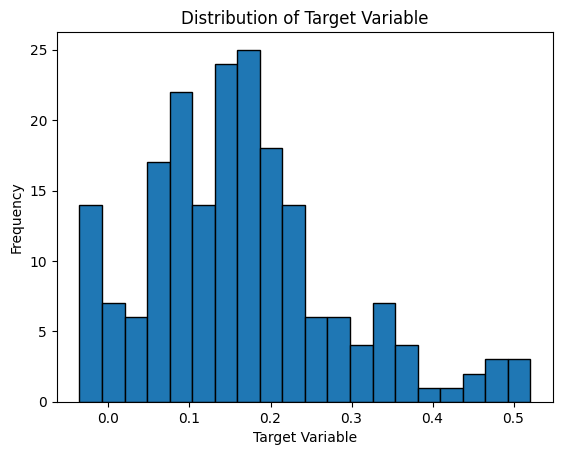

In [16]:
# Calculate target variable variance
variance = np.var(y)
print(f"Variance of target variable: {variance:.2f}")

# Plot histogram
plt.hist(y, bins=20, edgecolor="k")
plt.title("Distribution of Target Variable")
plt.xlabel("Target Variable")
plt.ylabel("Frequency")
plt.show()

Low variance in the target variable may indicate that the dataset is not diverse enough, needs to be altered or requires additional features. The MSE value indicates perfect predictions, but the r-squared can not be interpreted relaibly due to the target variable having low variance. 